# CuTe Layout Visualization Examples

This notebook demonstrates the visualization capabilities of the layouts library,
following examples from NVIDIA's CuTe (CUDA Templates) documentation.

All visualizations render inline — no files are written to disk.

**Reference:** [CuTe Documentation](https://github.com/NVIDIA/cutlass/blob/main/media/docs/cpp/cute/)

**Reference:** [MMA Atom Documentation](https://github.com/NVIDIA/cutlass/blob/main/media/docs/cpp/cute/0t_mma_atom.md)

In [ ]:
import warnings

warnings.filterwarnings("ignore", message="findfont")

In [ ]:
from tensor_layouts import Layout, Swizzle, compose, complement, logical_divide, logical_product, mode, size
from tensor_layouts.viz import draw_layout, draw_swizzle, draw_slice, draw_tv_layout, draw_mma_layout, draw_tiled_grid
from tensor_layouts.layout_utils import tile_mma_grid
from tensor_layouts.atoms import (
    SM70_8x8x4_F32F16F16F32_NT,
    SM75_16x8x8_F32F16F16F32_TN,
    SM80_16x8x8_F16F16F16F16_TN, SM80_16x8x16_F16F16F16F16_TN,
    SM89_16x8x32_F32E4M3E4M3F32_TN,
    SM90_16x8x4_F64F64F64F64_TN,
    SM90_64x8x16_F16F16F16_SS, SM90_64x64x16_F16F16F16_SS,
    SM100_128x128x16_F16F16F16_SS,
    SM120_16x8x32_F32E4M3E4M3F32_TN,
)

## 1. Basic 2D Layouts

A CuTe Layout maps logical coordinates to memory offsets via `shape` and `stride`.

- **Row-major** `(M,N):(N,1)` — consecutive elements in each row are adjacent in memory
- **Column-major** `(M,N):(1,M)` — consecutive elements in each column are adjacent

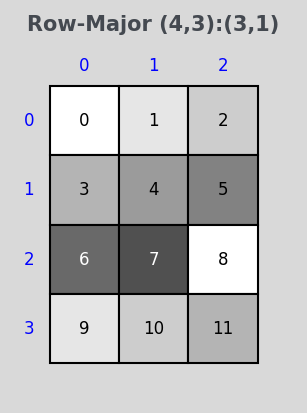

In [33]:
# Row-major 4×3: offset(i,j) = i*3 + j
draw_layout(Layout((4, 3), (3, 1)), title="Row-Major (4,3):(3,1)")

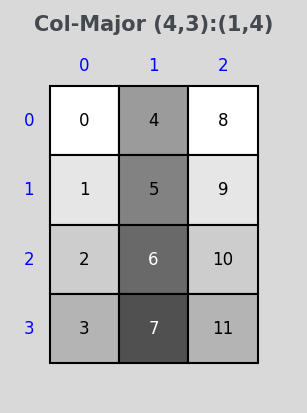

In [34]:
# Column-major 4×3: offset(i,j) = i + j*4
draw_layout(Layout((4, 3), (1, 4)), title="Col-Major (4,3):(1,4)")

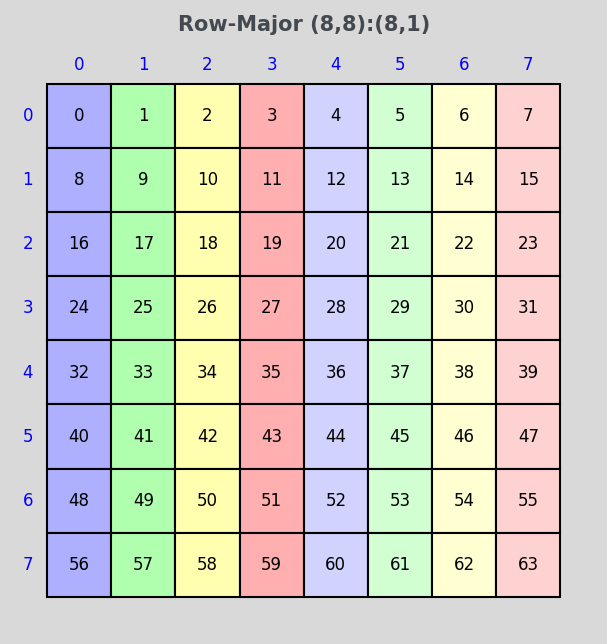

In [35]:
# 8×8 row-major with rainbow coloring
draw_layout(Layout((8, 8), (8, 1)), title="Row-Major (8,8):(8,1)", colorize=True)

## 2. Hierarchical Layouts

CuTe supports nested (hierarchical) shapes. A layout with shape `((2,3),(2,4))` describes
2×2 tiles arranged in a 3×4 grid — the inner dimensions describe the tile, outer dimensions
describe the grid of tiles.

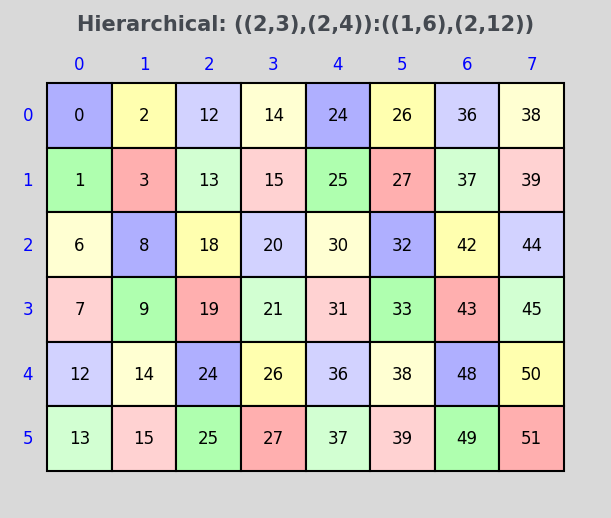

In [36]:
# 2×2 tiles in a 3×4 grid: ((2,3),(2,4)) : ((1,6),(2,12))
hier = Layout(((2, 3), (2, 4)), ((1, 6), (2, 12)))
draw_layout(hier, title="Hierarchical: ((2,3),(2,4)):((1,6),(2,12))", colorize=True)

## 3. Swizzled Layouts

Swizzle applies an XOR operation to indices, redistributing elements across memory banks
to avoid bank conflicts in GPU shared memory.

`Swizzle(B, M, S)`: XOR B bits starting at position M with bits at position M+S.

### Classic LDMATRIX Swizzles — `Swizzle(B, 0, 3)`

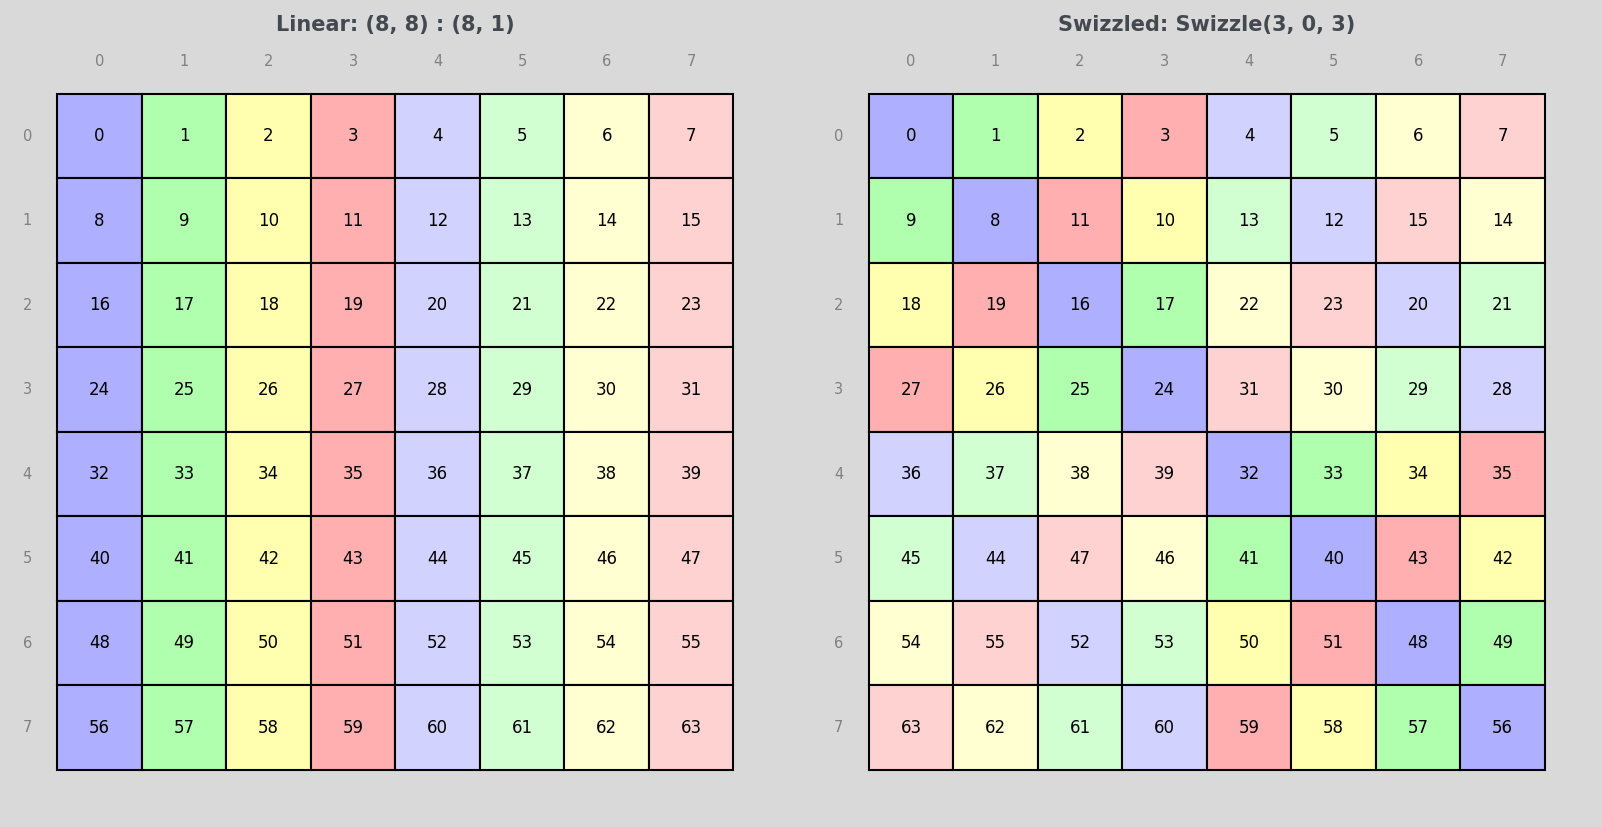

In [37]:
# Swizzle(3,0,3) on 8×8 — the classic LDMATRIX bank conflict avoidance pattern
draw_swizzle(Layout((8, 8), (8, 1)), Swizzle(3, 0, 3), colorize=True)

### GMMA/TMA Swizzles — `Swizzle(B, 4, 3)` (SM90+)

These operate on higher bits and are designed for the Tensor Memory Accelerator.
The block-level view shows 2^base elements per block, revealing the permutation pattern.

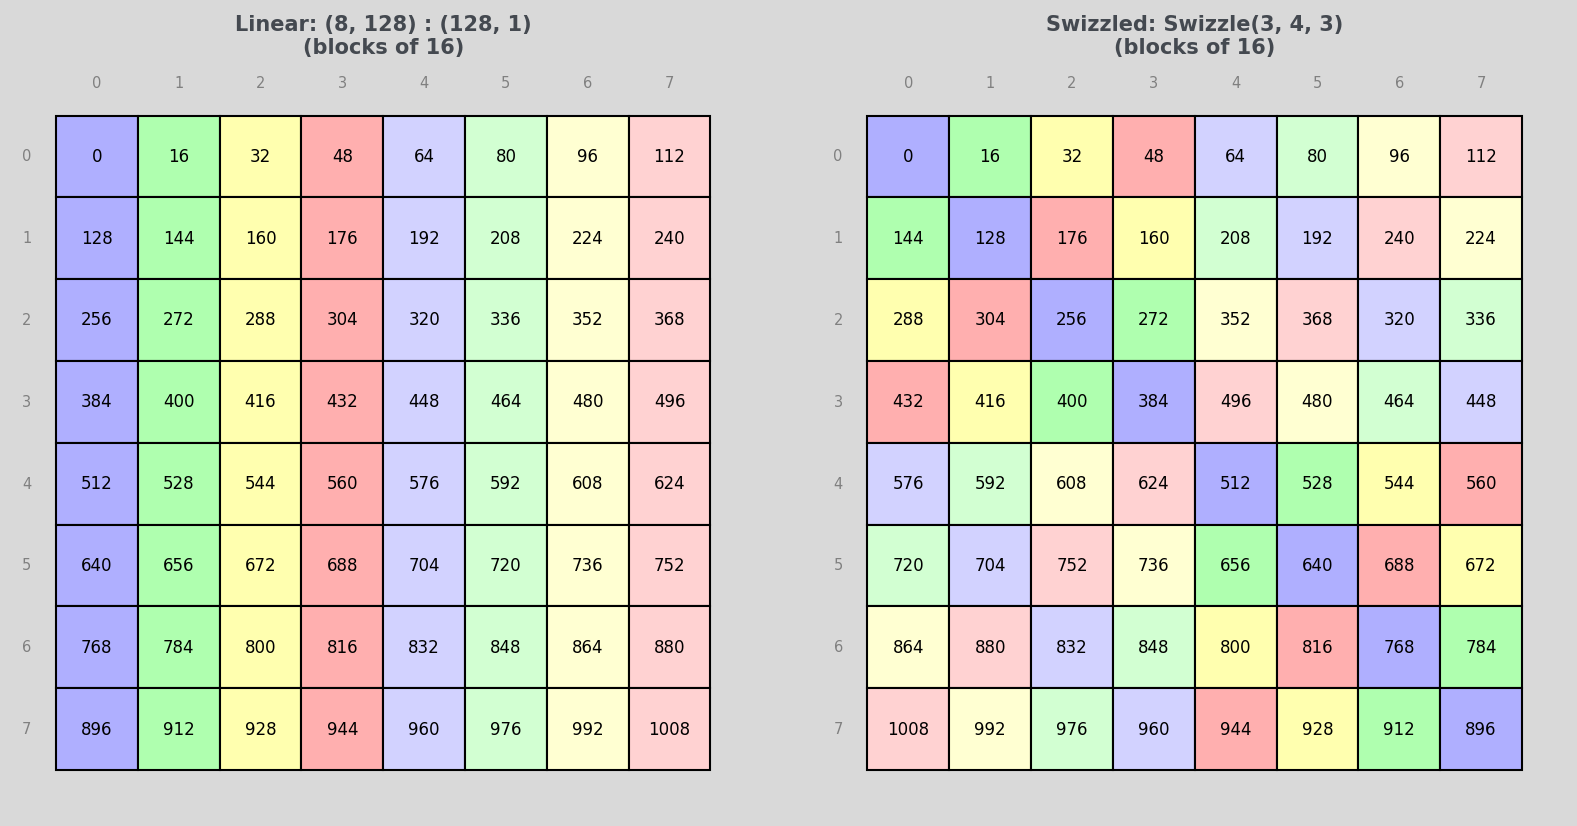

In [38]:
# SW128: Swizzle(3,4,3) on canonical byte layout 8×128
# Shown as block-level view (each cell = 16 elements)
draw_swizzle(Layout((8, 128), (128, 1)), Swizzle(3, 4, 3), colorize=True)

## 4. MMA Atom Traits

MMA atoms define how matrix multiplication operands are distributed across threads
for Tensor Core operations. Each atom is defined by its A, B, C layouts from the
CuTe `MMA_Traits` struct.

The layouts map `(thread_idx, value_idx) → element coordinate` using column-major
encoding: `offset = m + n*M` for an M×N matrix.

### SM70 Volta — `SM70_8x8x4_F32F16F16F32_NT`

8 threads (one quadpair), Shape 8×8×4. This is the example from
[0t_mma_atom.md](https://github.com/NVIDIA/cutlass/blob/main/media/docs/cpp/cute/0t_mma_atom.md).

Equivalent to:
```cpp
MMA_Atom mma = MMA_Atom<SM70_8x8x4_F32F16F16F32_NT>{};
print_latex(mma);
```

In [39]:
atom = SM70_8x8x4_F32F16F16F32_NT
M, N, K = atom.shape_mnk
print(f"{atom.name}  Shape: {M}×{N}×{K}")
print(f"  PTX: {atom.ptx}")
print(f"  A layout: {atom.a_layout}")
print(f"  B layout: {atom.b_layout}")
print(f"  C layout: {atom.c_layout}")

SM70_8x8x4_F32F16F16F32_NT  Shape: 8×8×4
  PTX: mma.sync.aligned.m8n8k4.col.row.f32.f16.f16.f32
  A layout: ((4, 2), 4) : ((8, 4), 1)
  B layout: ((4, 2), 4) : ((8, 4), 1)
  C layout: ((2, 2, 2), (2, 2, 2)) : ((1, 16, 4), (8, 2, 32))


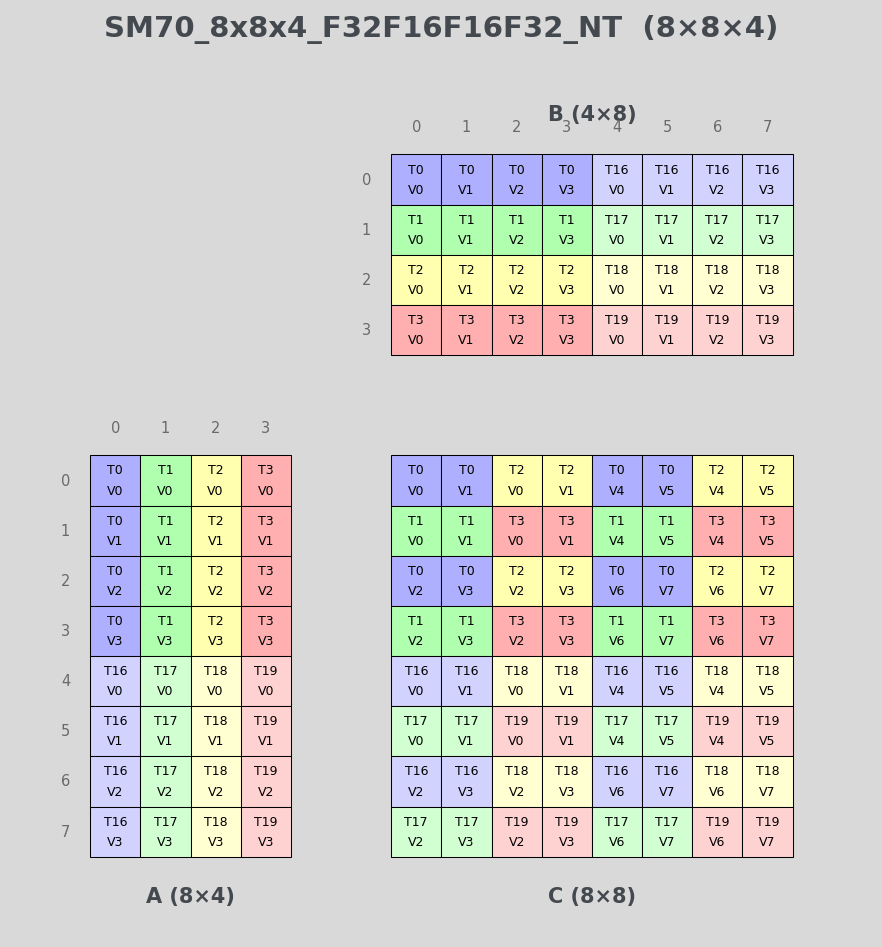

In [40]:
# Composite A, B, C visualization
draw_mma_layout(atom.a_layout, atom.b_layout, atom.c_layout,
                tile_mnk=(M, N, K), colorize=True, thr_id_layout=atom.thr_id,
                main_title=f"{atom.name}  ({M}×{N}×{K})")

### Tiled MMA — 2×2 Atom Layout (Full Warp)

Tiling the atom with a `(2,2):(2,1)` n-major layout creates a 16×16×4 MMA
using all 32 threads (4 quadpairs = full warp).

Equivalent to:
```cpp
TiledMMA mma = make_tiled_mma(SM70_8x8x4_F32F16F16F32_NT{},
                              Layout<Shape<_2,_2>, Stride<_2,_1>>{});
print_latex(mma);
```

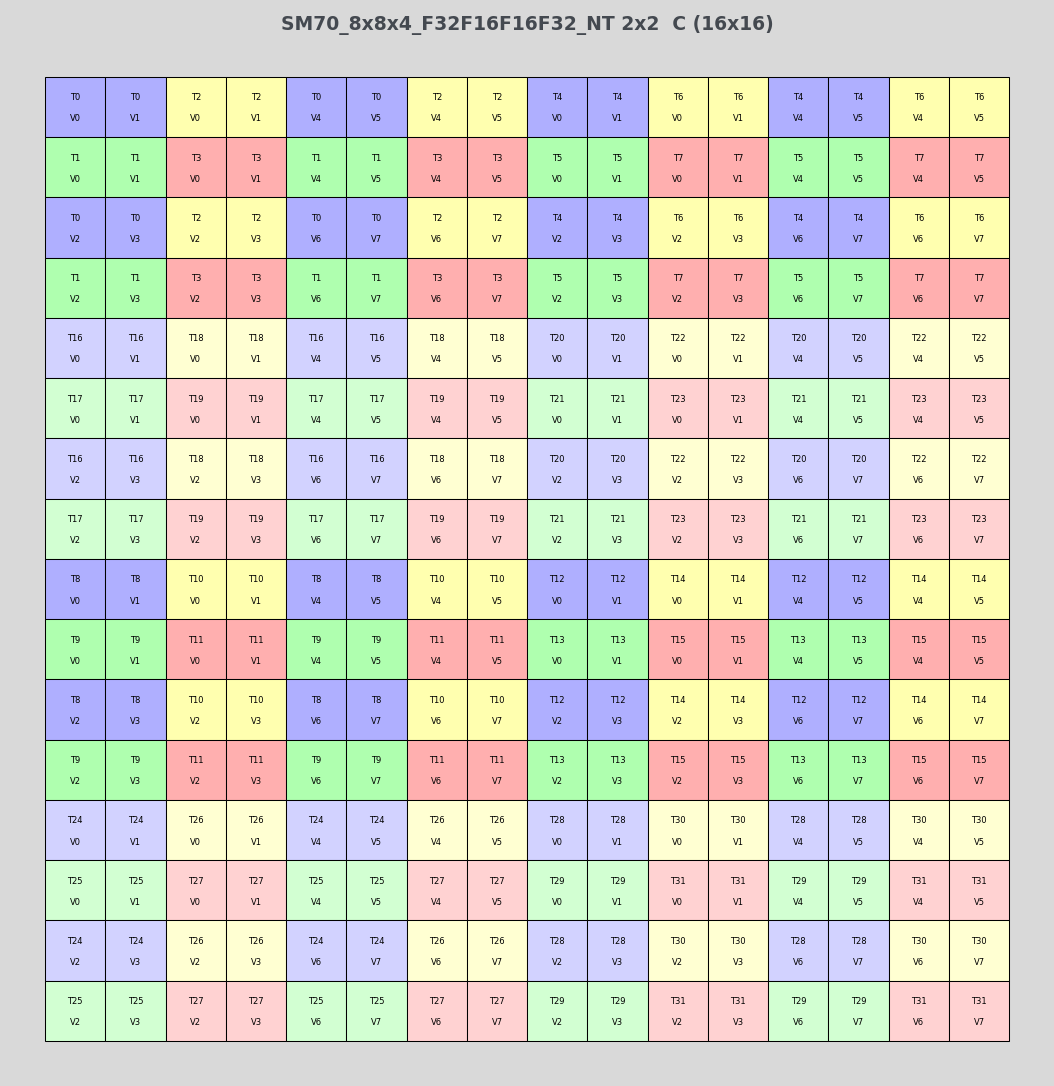

In [41]:
# 2x2 tiled C matrix (16x16)
atom_layout = Layout((2, 2), (2, 1))
c_grid, _ = tile_mma_grid(atom, atom_layout, 'C')
draw_tiled_grid(c_grid, 16, 16, title=f"{atom.name} 2x2  C (16x16)")

### Tiled MMA — 32×32×4 (Value Tiling)

Expanding the tile to 32×32×4 replicates across **values** (not threads).
Each 16×16 quadrant uses the same threads but new value indices.

Equivalent to:
```cpp
TiledMMA mma = make_tiled_mma(SM70_8x8x4_F32F16F16F32_NT{},
                              Layout<Shape<_2,_2>, Stride<_2,_1>>{},
                              Tile<_32,_32,_4>{});
print_latex(mma);
```

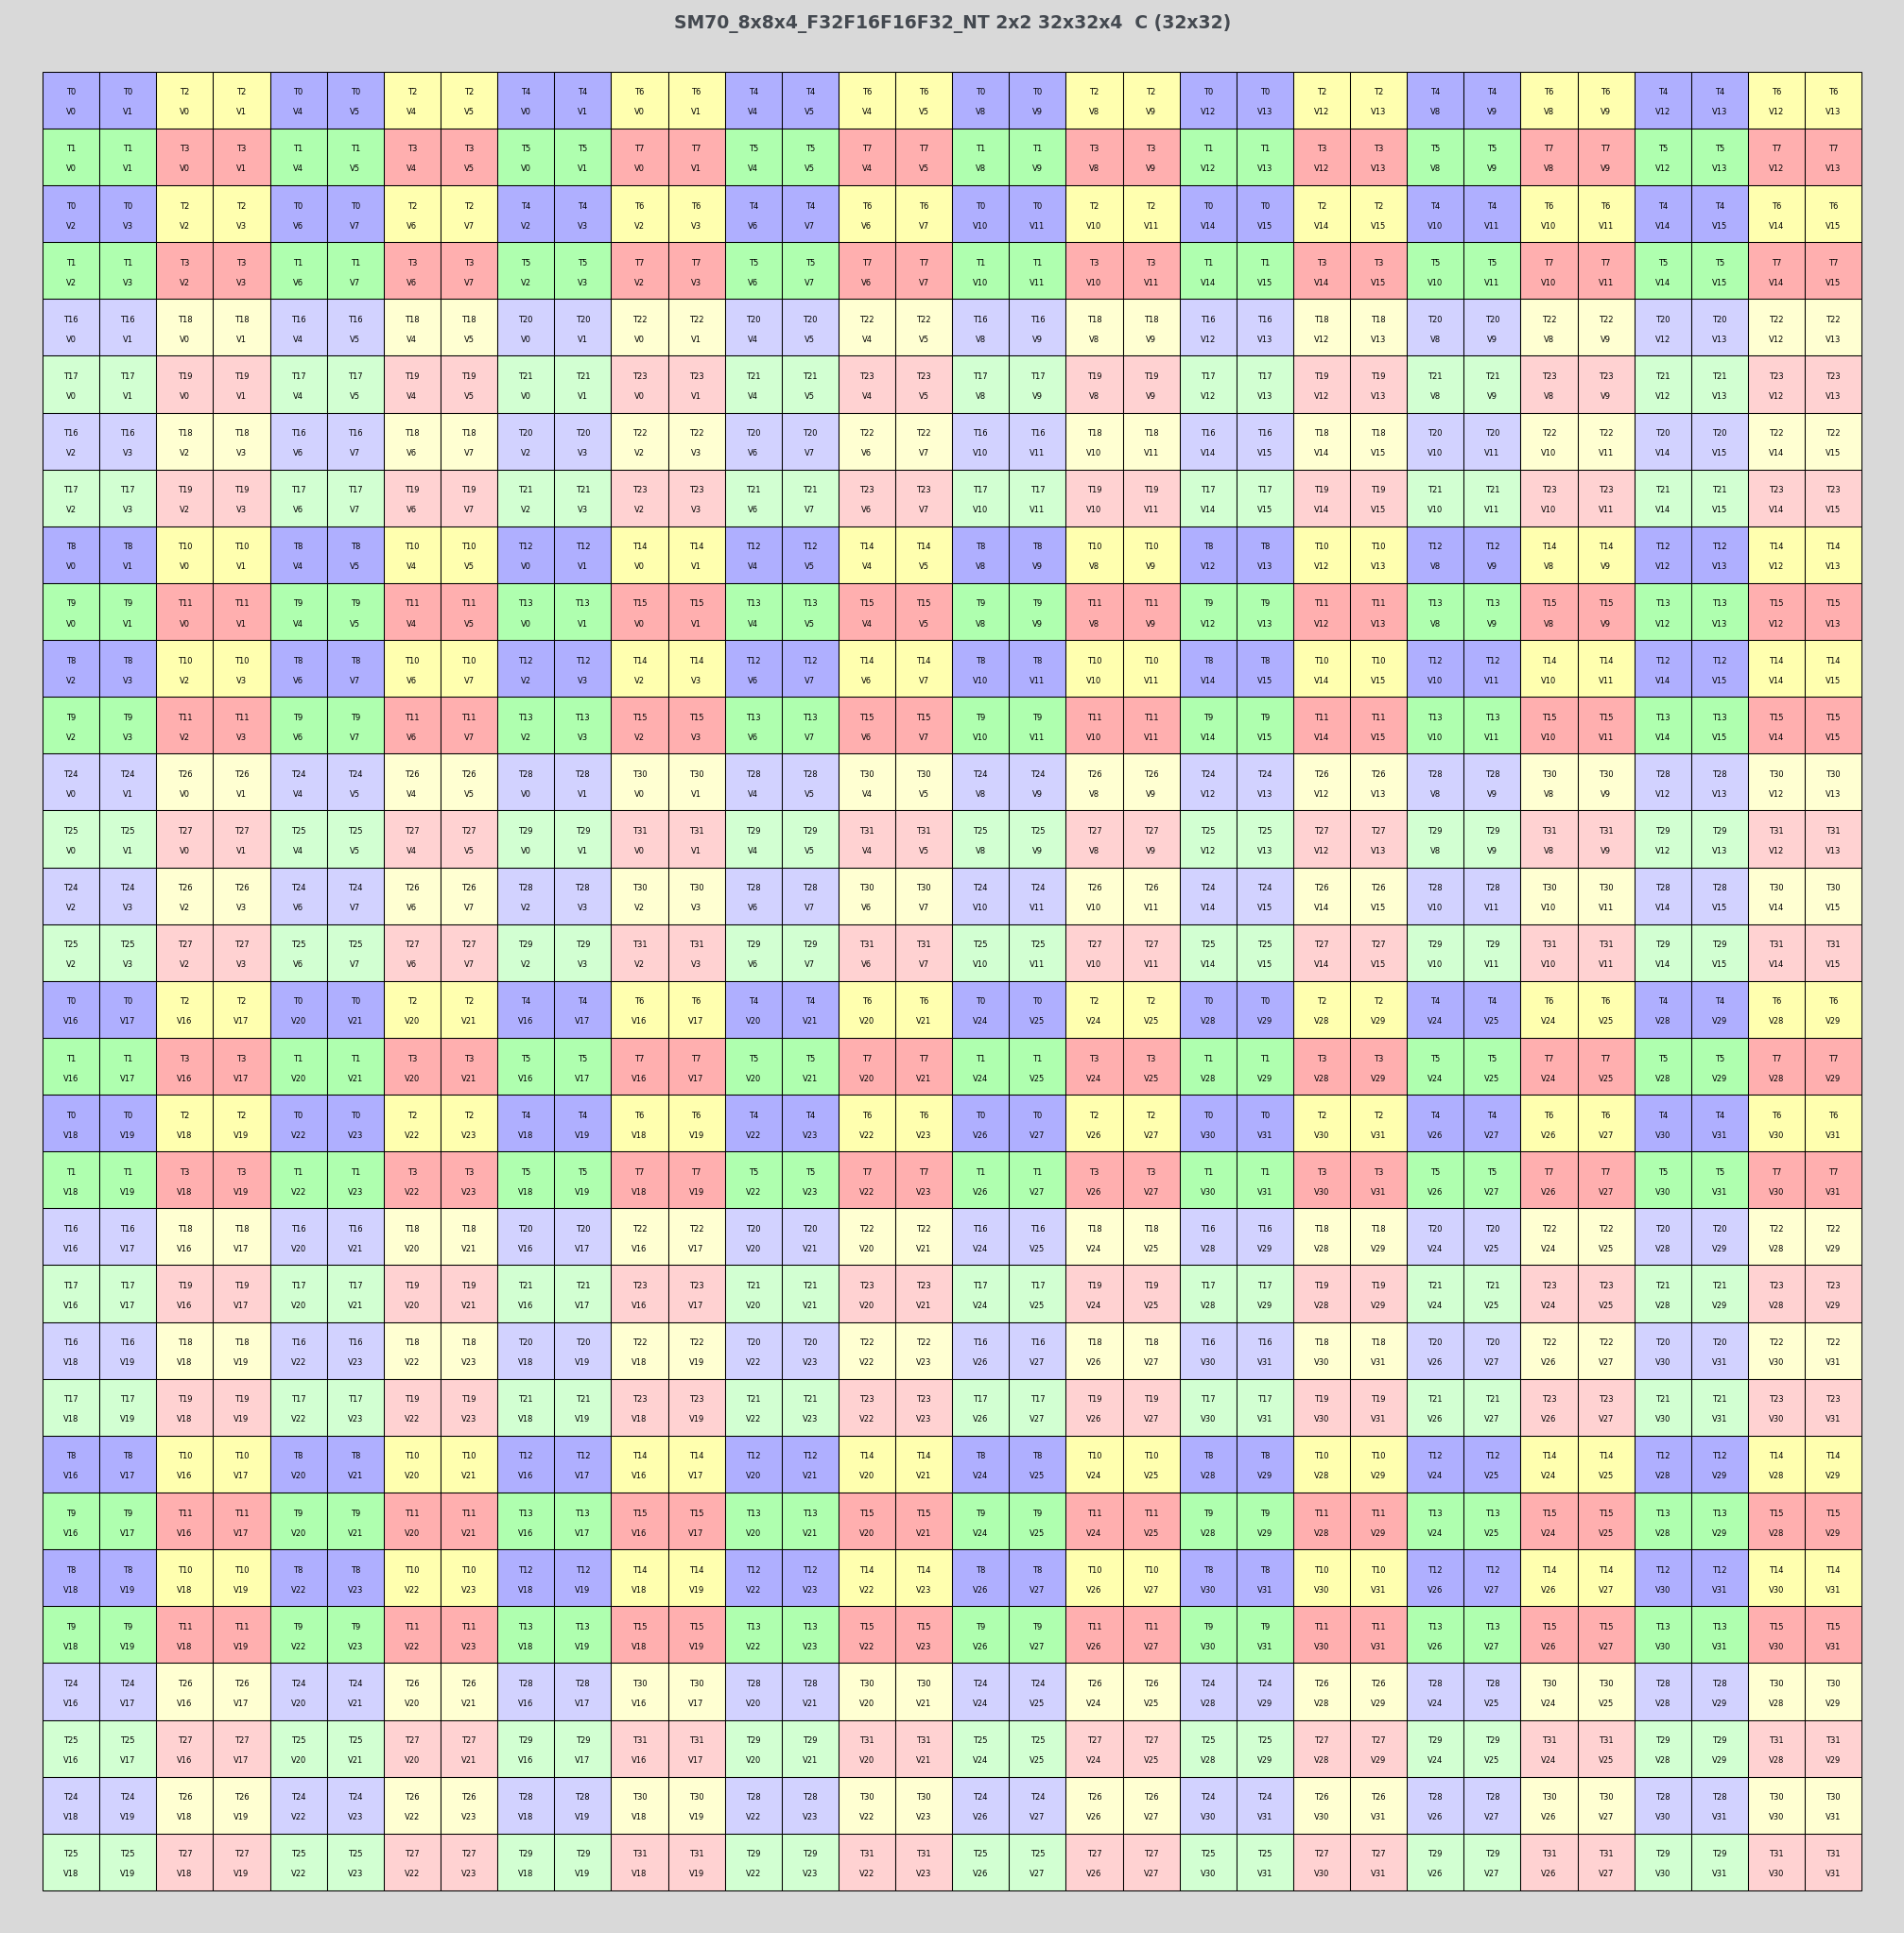

In [42]:
# 32x32x4 tiled C matrix
c_grid_32, _ = tile_mma_grid(atom, atom_layout, 'C', tile_mnk=(32, 32, 4))
draw_tiled_grid(c_grid_32, 32, 32, title=f"{atom.name} 2x2 32x32x4  C (32x32)")

### SM80 Ampere — `SM80_16x8x8_F16F16F16F16_TN`

32 threads (one warp), Shape 16×8×8. From `mma_traits_sm80.hpp`.

PTX: `mma.sync.aligned.m16n8k8.row.col.f16.f16.f16.f16`

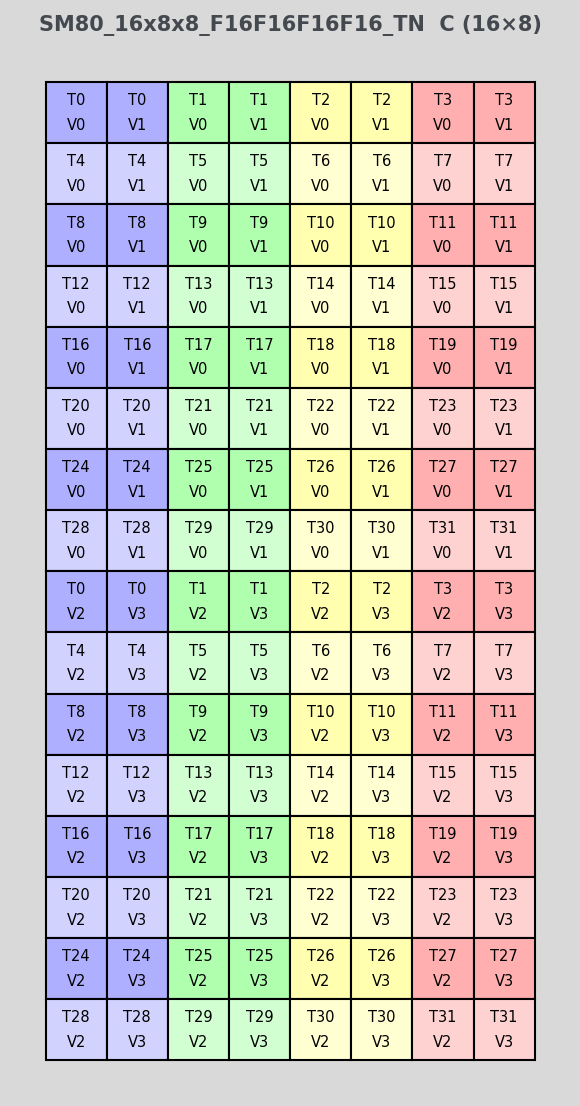

In [43]:
atom = SM80_16x8x8_F16F16F16F16_TN
M, N, K = atom.shape_mnk
draw_tv_layout(atom.c_layout, title=f"{atom.name}  C ({M}×{N})",
               colorize=True, grid_shape=(M, N))

### SM90 GMMA — Warpgroup Accumulator

128 threads (warpgroup = 4 warps). A and B operands come from shared memory
descriptors. The C accumulator layout shows register distribution.

From `mma_traits_sm90_gmma.hpp`, `CLayout_64xN` template.

SM90_64x64x16_F16F16F16_SS  Shape: 64×64×16
  128 threads × 32 vals/thr = 4096 elements


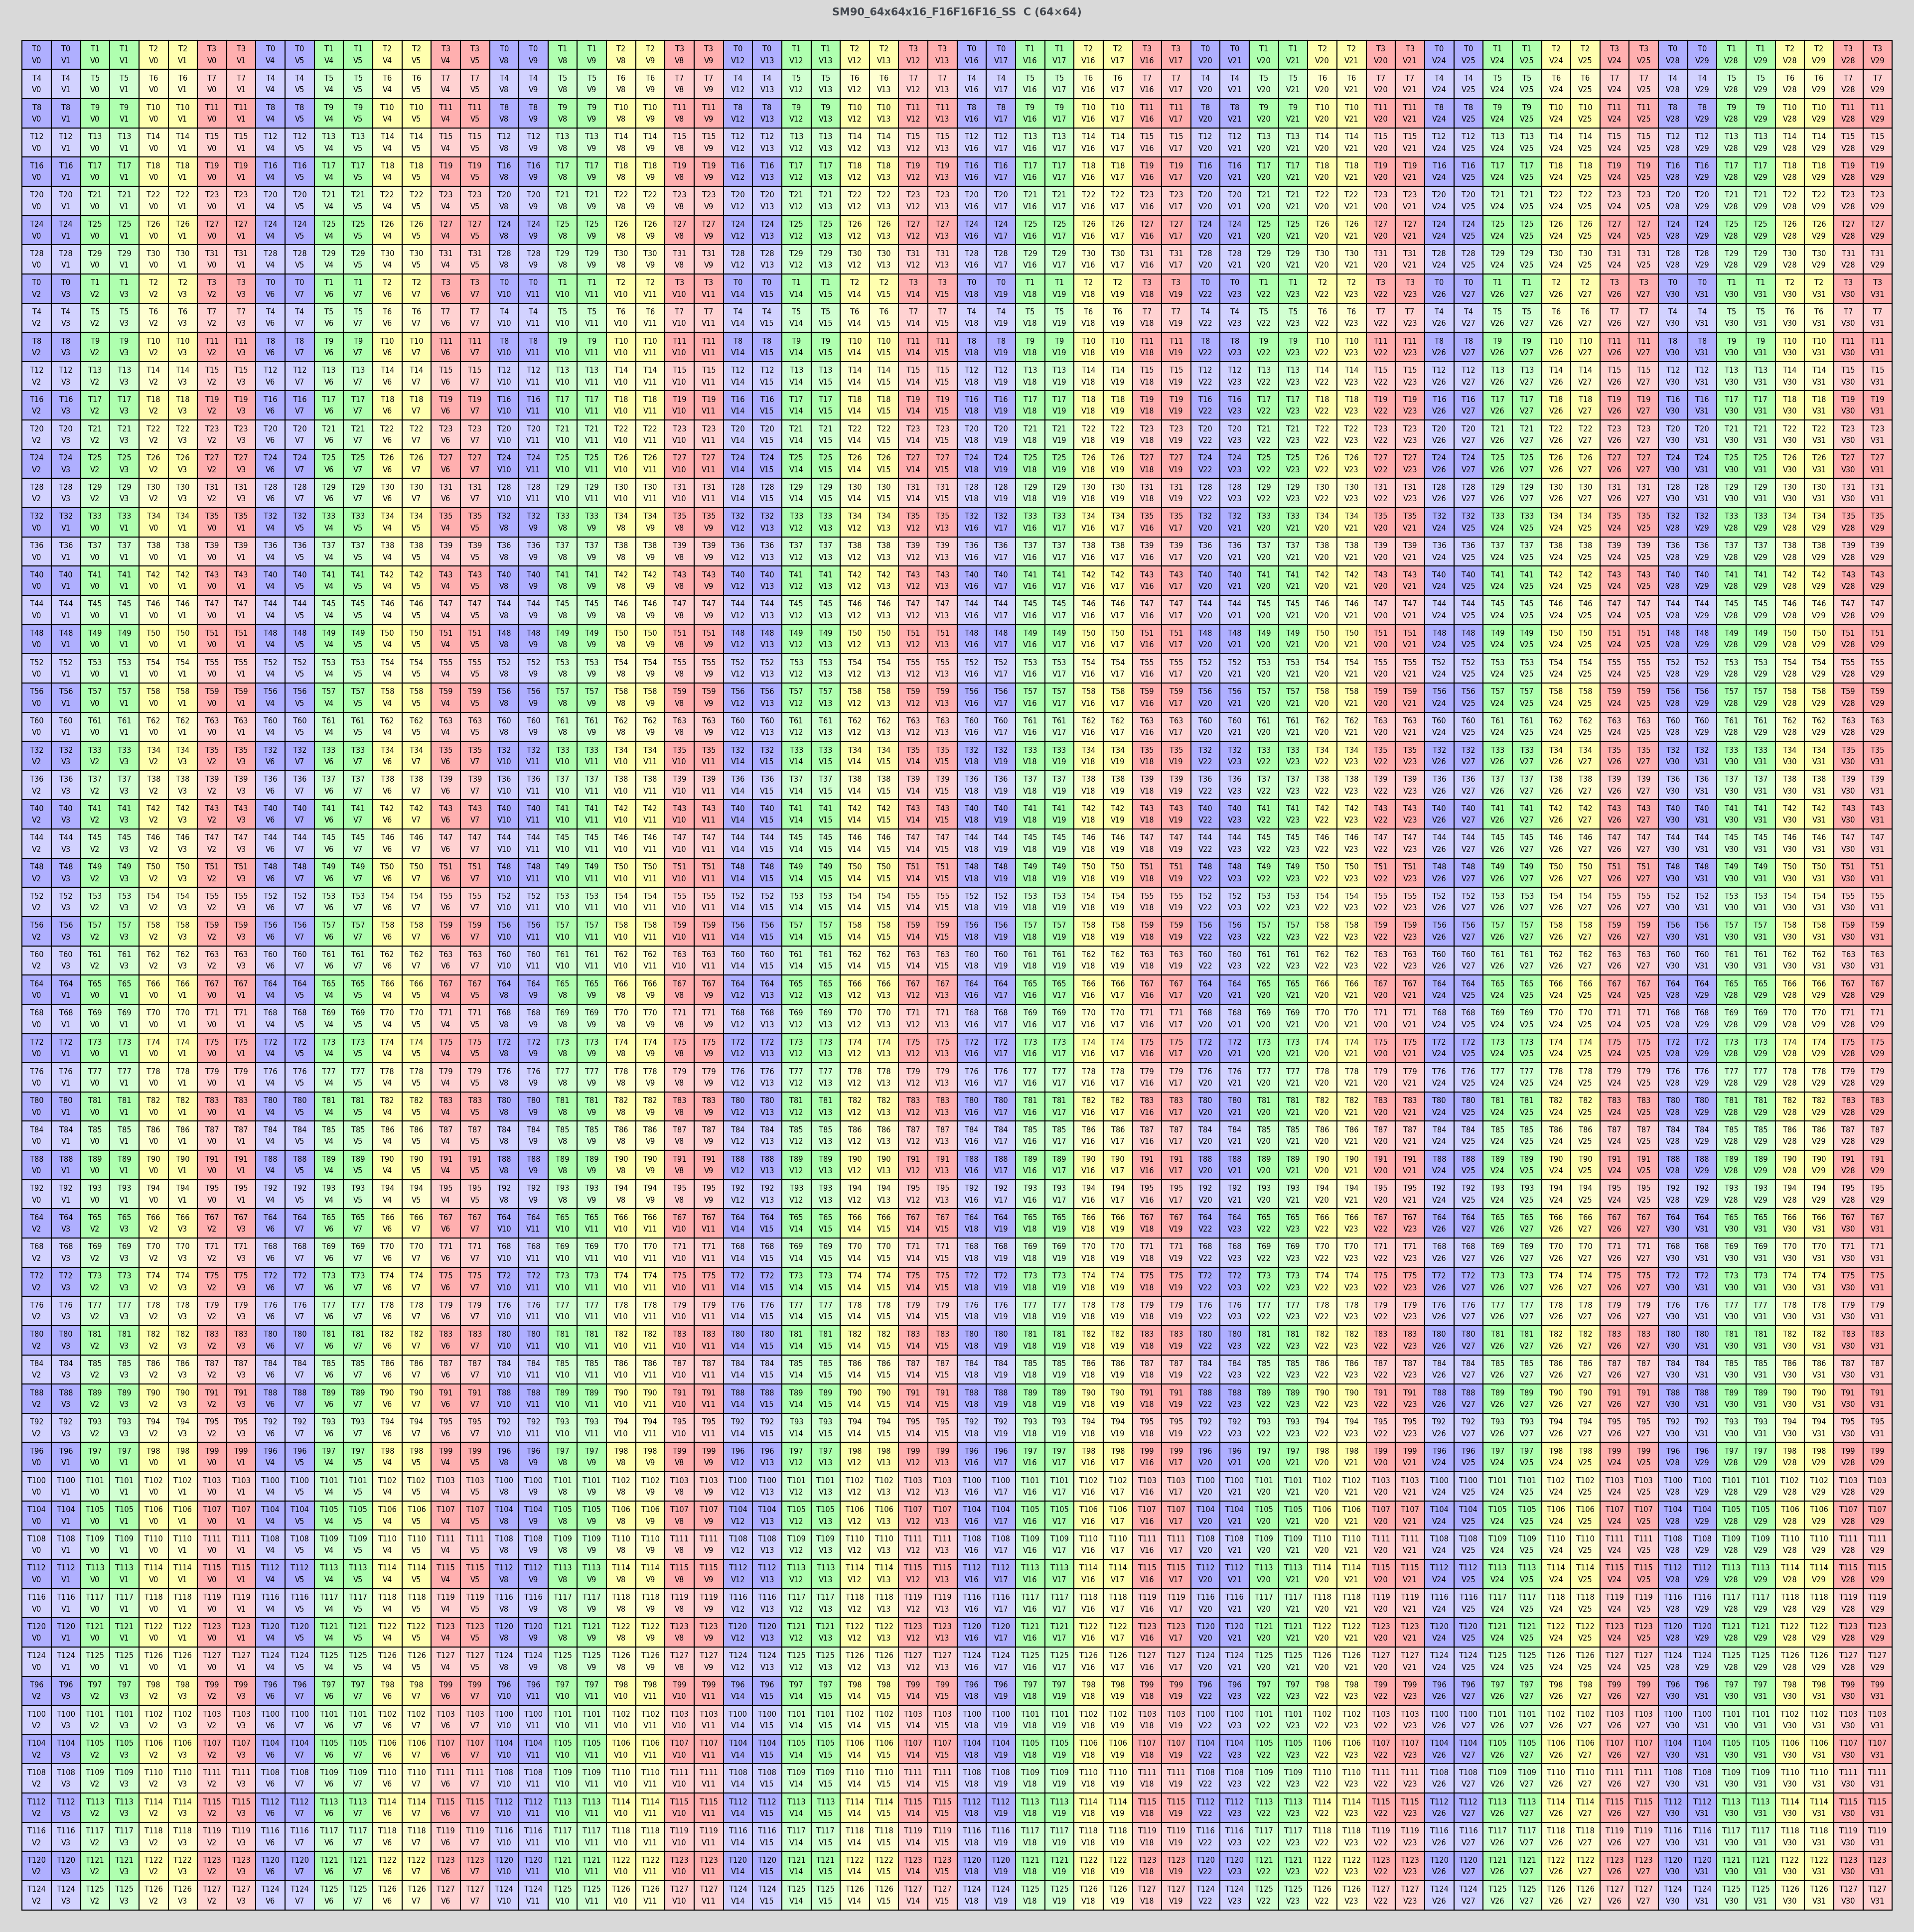

In [44]:
atom = SM90_64x64x16_F16F16F16_SS
M, N, K = atom.shape_mnk
print(f"{atom.name}  Shape: {M}×{N}×{K}")
print(f"  128 threads × {size(mode(atom.c_layout, 1))} vals/thr = {M*N} elements")
draw_tv_layout(atom.c_layout, title=f"{atom.name}  C ({M}×{N})",
               colorize=True, grid_shape=(M, N))

### SM75 Turing — `SM75_16x8x8_F32F16F16F32_TN`

32 threads (one warp), Shape 16×8×8. First generation of asymmetric tensor core tiles.

PTX: `mma.sync.aligned.m16n8k8.row.col.f32.f16.f16.f32`

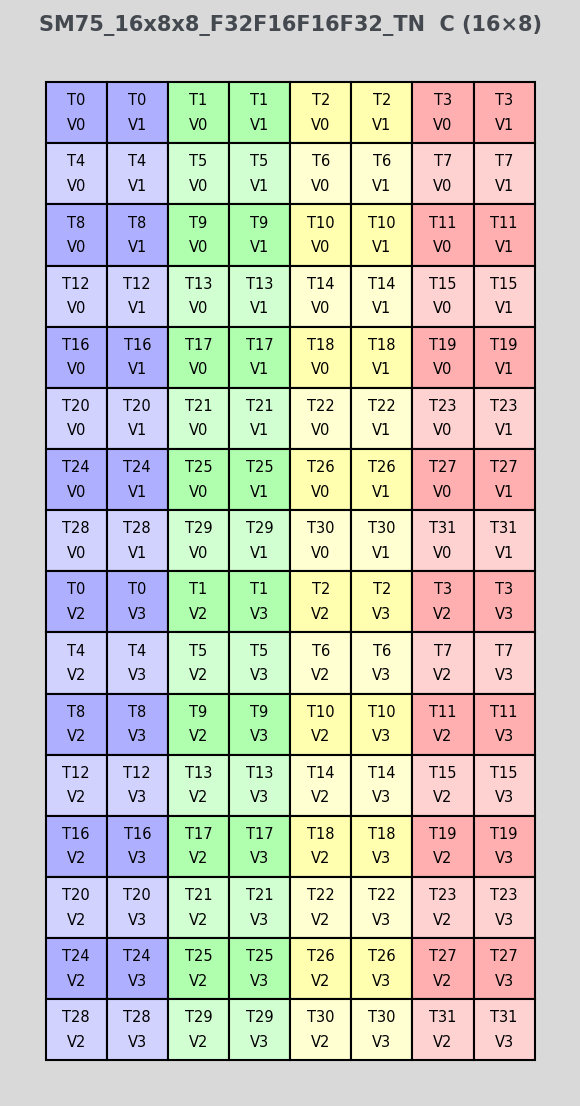

In [45]:
atom = SM75_16x8x8_F32F16F16F32_TN
M, N, K = atom.shape_mnk
draw_tv_layout(atom.c_layout, title=f"{atom.name}  C ({M}×{N})",
               colorize=True, grid_shape=(M, N))

### SM89 Ada Lovelace — `SM89_16x8x32_F32E4M3E4M3F32_TN`

32 threads (one warp), Shape 16×8×32. First FP8 (E4M3/E5M2) tensor cores.

PTX: `mma.sync.aligned.m16n8k32.row.col.f32.e4m3.e4m3.f32`

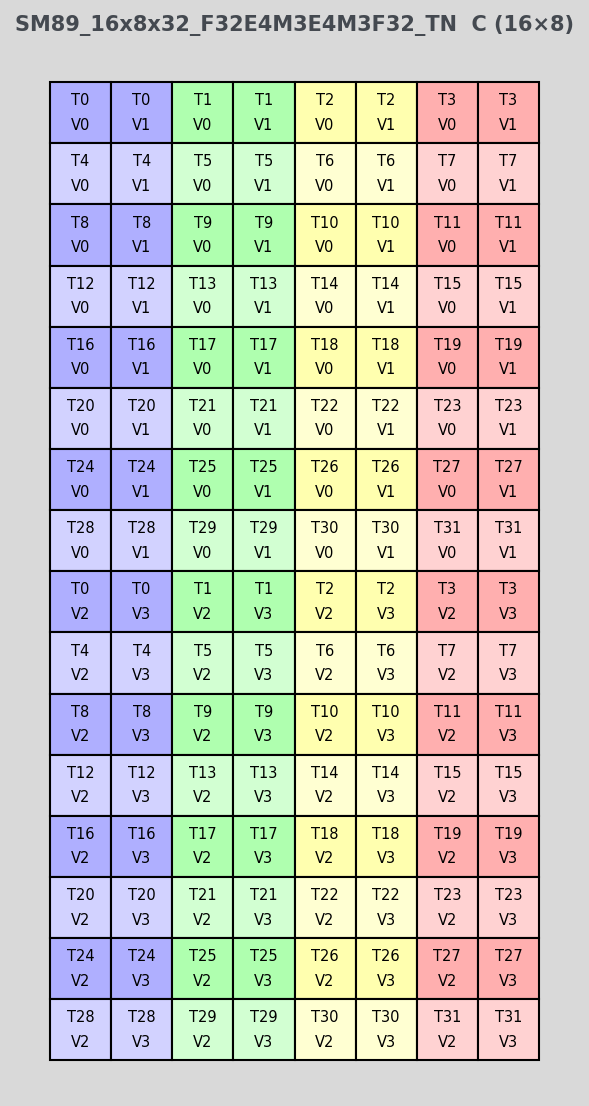

In [46]:
atom = SM89_16x8x32_F32E4M3E4M3F32_TN
M, N, K = atom.shape_mnk
draw_tv_layout(atom.c_layout, title=f"{atom.name}  C ({M}×{N})",
               colorize=True, grid_shape=(M, N))

### SM100 Blackwell UMMA — `SM100_128x128x16_F16F16F16_SS`

1 "thread" (warp group operates as a unit via TMEM). Shape 128×128×16.

SM100 uses a fundamentally different model from SM90: instead of distributing
elements across 128 threads with a hierarchical layout, all elements live in
TMEM (Tensor Memory) accessible by the entire warp group as a single unit.

The layout is trivial col-major: `(1, (M, N)) : (0, (1, M))`.

Below we compare the SM90 GMMA and SM100 UMMA representations of the same
64×8 C accumulator tile.

In [ ]:
from tensor_layouts.atoms import _gmma_c_layout, _umma_layout

# SM90 GMMA 64×8 C: 128 threads, hierarchical layout
sm90_c = _gmma_c_layout(8)
print(f"SM90 GMMA  64×8 C: {sm90_c}")
draw_tv_layout(sm90_c, title="SM90 GMMA  C (64×8) — 128 threads",
               colorize=True, grid_shape=(64, 8))

# SM100 UMMA 64×8 C: 1 thread, simple col-major
umma_c = _umma_layout(64, 8)
print(f"\nSM100 UMMA 64×8 C: {umma_c}")
draw_layout(umma_c, title="SM100 UMMA  C (64×8) — 1 thread, TMEM",
            flatten_hierarchical=True)

### SM120 Blackwell B200 — `SM120_16x8x32_F32E4M3E4M3F32_TN`

32 threads (one warp), Shape 16×8×32. Warp-level FP8 with block scaling support.

PTX: `mma.sync.aligned.m16n8k32.row.col.f32.e4m3.e4m3.f32`

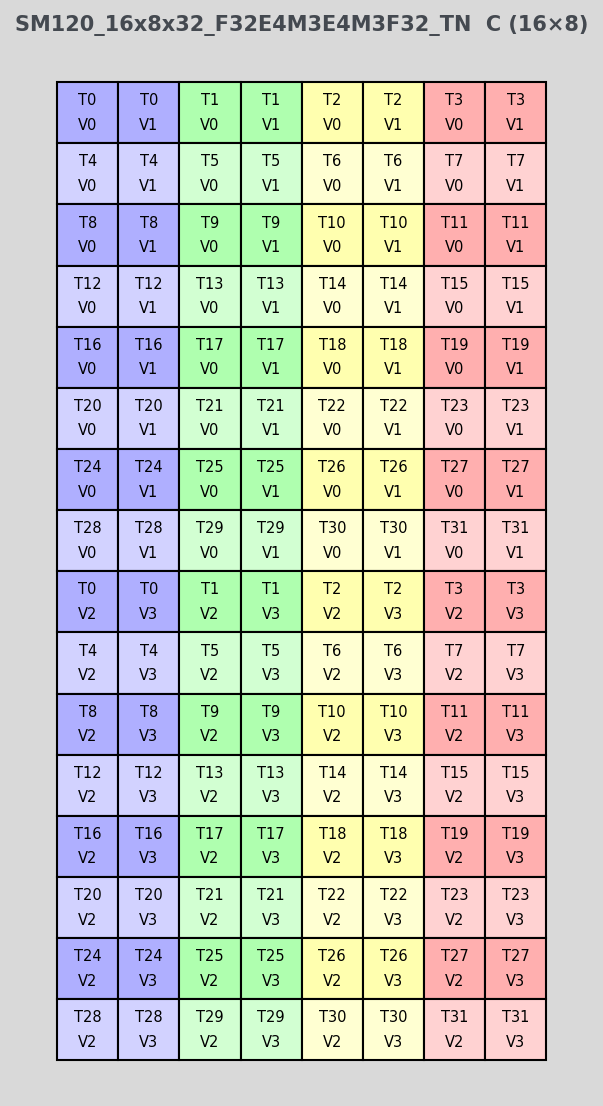

In [48]:
atom = SM120_16x8x32_F32E4M3E4M3F32_TN
M, N, K = atom.shape_mnk
draw_tv_layout(atom.c_layout, title=f"{atom.name}  C ({M}×{N})",
               colorize=True, grid_shape=(M, N))

## 5. Slicing — Cecka, "CuTe Layout Representation and Algebra"

Slicing fixes some coordinates while leaving others free (`None`).
For hierarchical layouts, slice specs mirror the shape tree — use `None` for free modes
and integer values to fix a coordinate at that level.

### Simple Slicing

Simple row and column slicing on an 8×8 row-major layout.

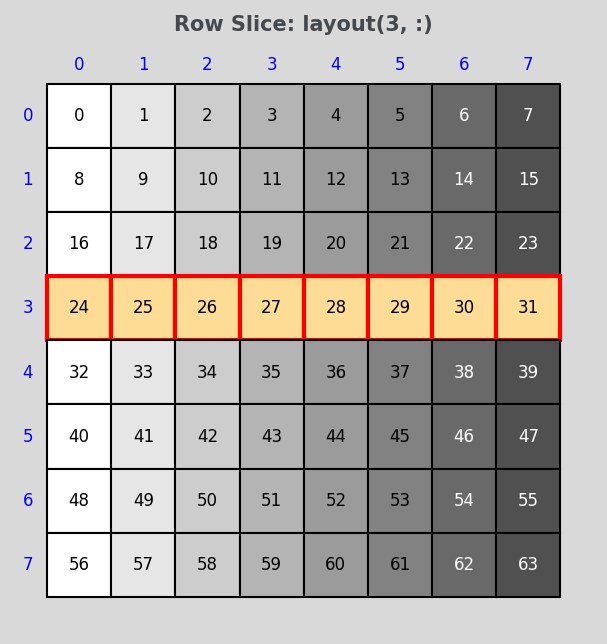

In [49]:
base = Layout((8, 8), (8, 1))

# Row slice: select row 3
draw_slice(base, (3, None), title="Row Slice: layout(3, :)")

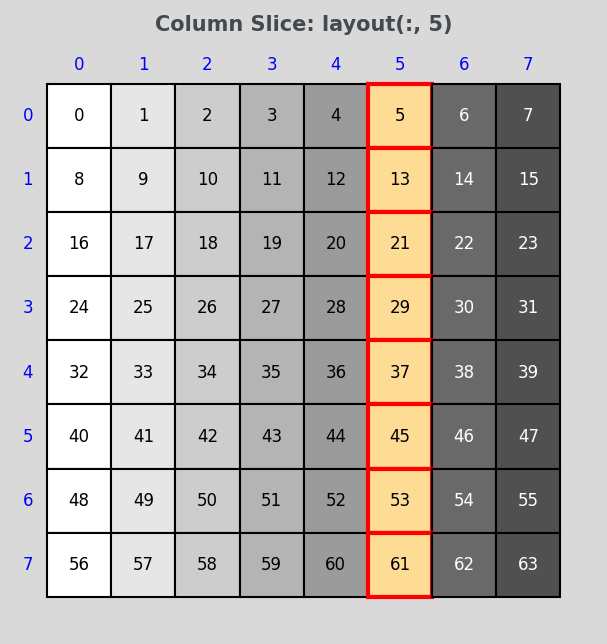

In [50]:
# Column slice: select column 5
draw_slice(base, (None, 5), title="Column Slice: layout(:, 5)")

### Hierarchical Slicing

These examples are from Cecka, "CuTe Layout Representation and Algebra".
The base tensor has deeply nested structure in both modes:

**Base tensor:** `((3,2),((2,3),2)):((4,1),((2,15),100))`

Tensor: ((3, 2), ((2, 3), 2)) : ((4, 1), ((2, 15), 100))


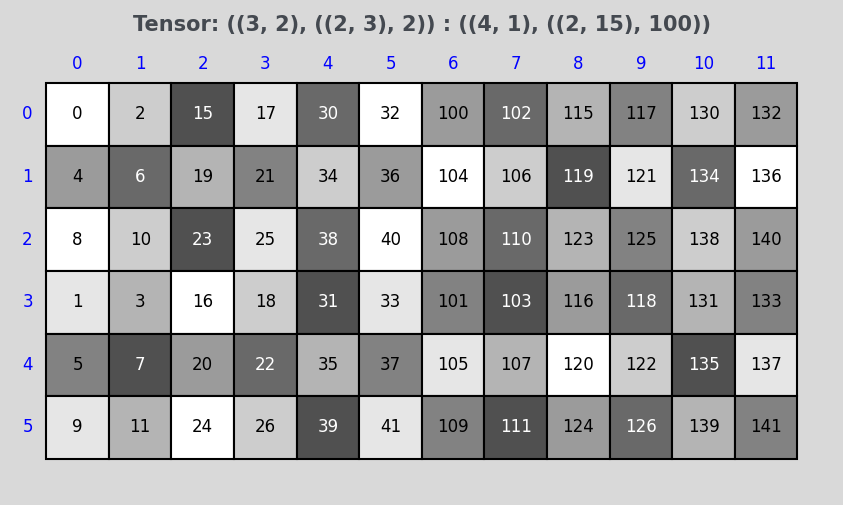

In [51]:
cecka_t = Layout(((3, 2), ((2, 3), 2)), ((4, 1), ((2, 15), 100)))
print(f"Tensor: {cecka_t}")
draw_layout(cecka_t, title=f"Tensor: {cecka_t}", flatten_hierarchical=True)

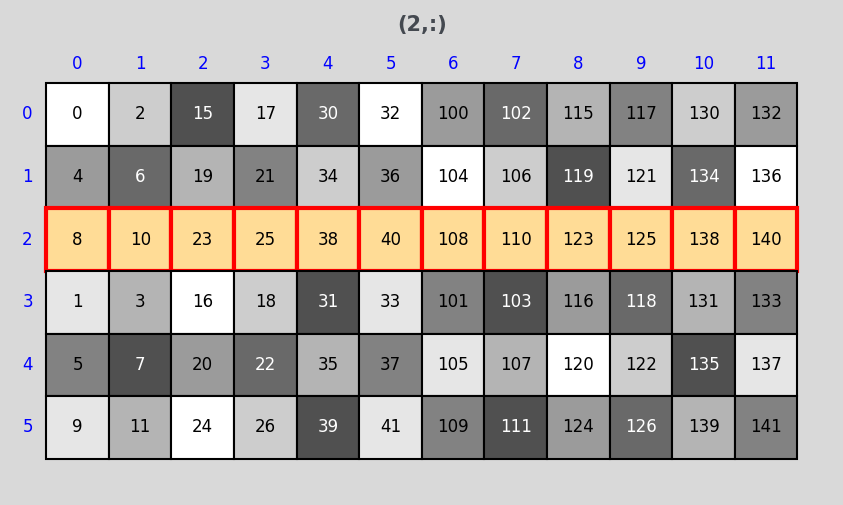

In [52]:
# (2,:) — fix mode-0 to flat index 2, keep all of mode-1
draw_slice(cecka_t, (2, None), title="(2,:)")

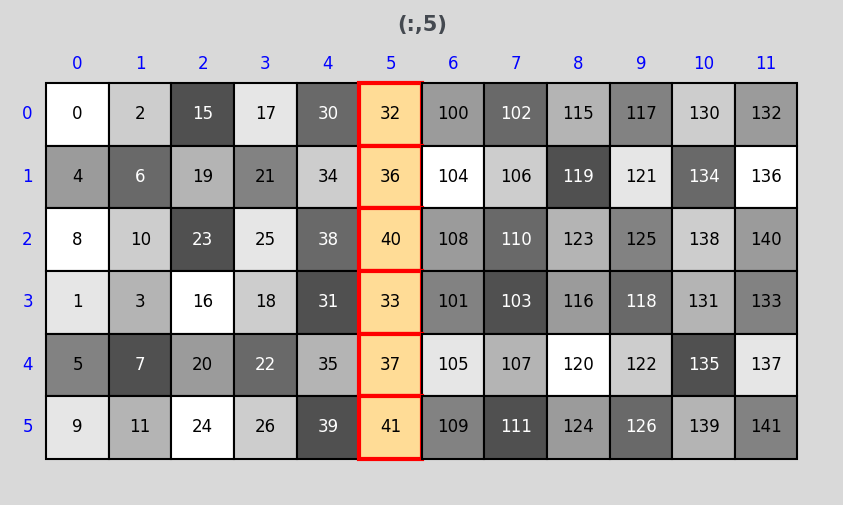

In [53]:
# (:,5) — keep all of mode-0, fix mode-1 to flat index 5
draw_slice(cecka_t, (None, 5), title="(:,5)")

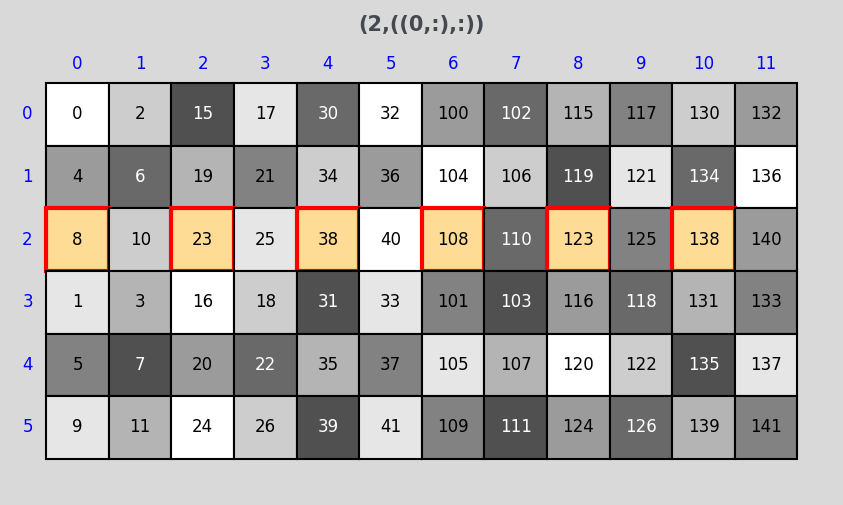

In [54]:
# (2,((0,:),:)) — fix mode-0 to 2, partially slice mode-1
draw_slice(cecka_t, (2, ((0, None), None)), title="(2,((0,:),:))")

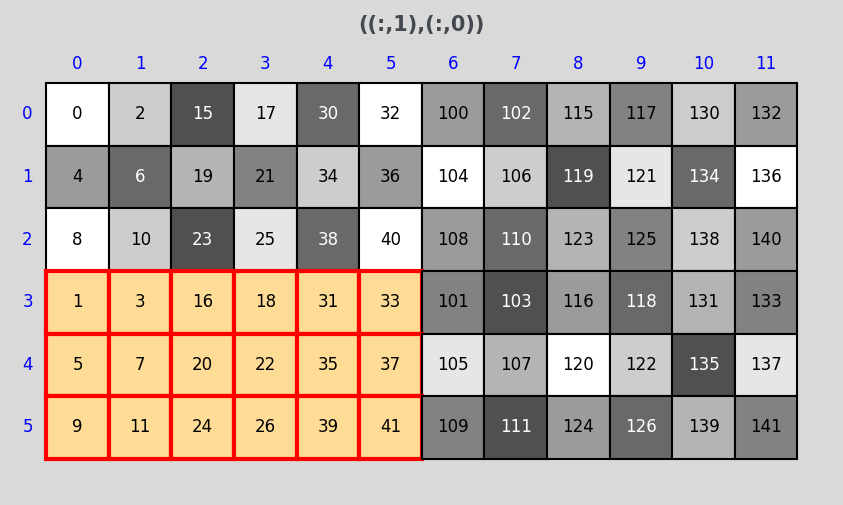

In [55]:
# ((:,1),(:,0)) — fix outer-row=1, inner-col-outer=0
draw_slice(cecka_t, ((None, 1), (None, 0)), title="((:,1),(:,0))")

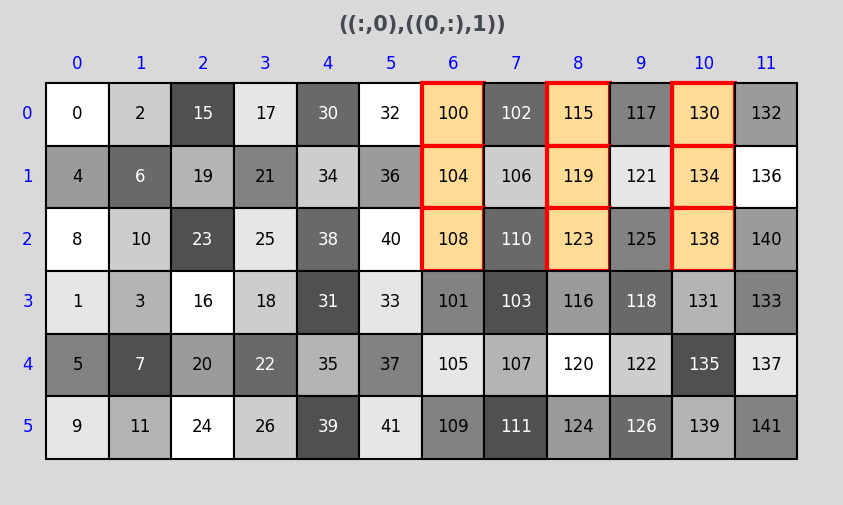

In [56]:
# ((:,0),((0,:),1)) — outer-row=0, inner-col-0=0, outer-col=1
draw_slice(cecka_t, ((None, 0), ((0, None), 1)), title="((:,0),((0,:),1))")

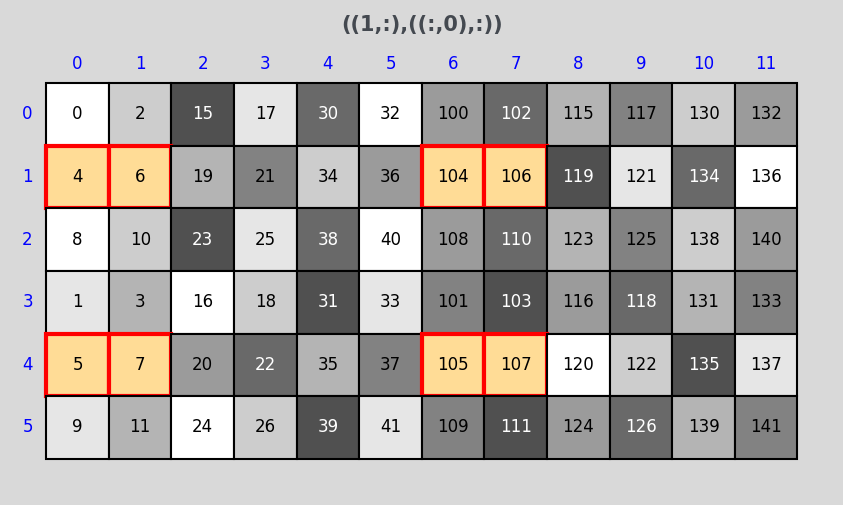

In [57]:
# ((1,:),((:,0),:)) — inner-row=1, middle-col=0
draw_slice(cecka_t, ((1, None), ((None, 0), None)), title="((1,:),((:,0),:))")